In [48]:
import os, random
from pathlib import Path

from PIL import Image
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt

import torch
from torchvision import transforms

In [ ]:
FRAMES_TO_STACK = 16
DOWNSAMPLING_SIZE = 256
CROP_SIZE = 224

In [13]:
BASE_DIR = Path(r"/home/prolex/prokhor_grasp_labeller/dataset")

In [14]:
tested_iteration = BASE_DIR / random.sample(os.listdir(BASE_DIR), 1)[0]
camera_meta_path = tested_iteration / "opentouch/digit360/index/camera/camera.csv"
# phase_data_path = tested_iteration / "grasp/grasp_phases.csv"
frames_path = tested_iteration / "opentouch/digit360/index/camera/frames"

In [15]:
frames_meta = pd.read_csv(camera_meta_path)
# phase_data = pd.read_csv(phase_data_path)

In [100]:
last_frames_names = [frames_path / filename for filename in frames_meta.sort_values(by="time_perf", axis=0)["filename"].iloc[-FRAMES_TO_STACK:]]
first_frame_path = frames_path / (frames_meta.sort_values(by="time_perf", axis=0)["filename"].iloc[0])

In [93]:
cv2.cvtColor(cv2.imread(last_frames_names[-1], cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB).shape

(690, 690, 3)

In [84]:
frames = []

for frame_path in last_frames_names:
    path = frames_path / frame_path
    img_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img_bgr is None:
        raise FileNotFoundError(path)

    frames.append(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))

frames_arr = np.stack(frames, axis=0)
img = np.round(frames_arr.astype(np.float32).mean(axis=0)).astype(np.uint8)

In [101]:
background = cv2.imread(str(first_frame_path), cv2.IMREAD_COLOR)
background = cv2.cvtColor(background, cv2.COLOR_BGR2RGB)

In [94]:
class RemoveBackground:
    def __init__(self, bgr):
        self.bgr = bgr

    def __call__(self, img):
        assert img.shape == self.bgr.shape
        return img - self.bgr

class Cv2ToRgb:
    def __call__(self, img):
        # img: BGR numpy array from cv2
        return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

class Cv2Resize:
    def __init__(self, size, interpolation=cv2.INTER_AREA):
        self.size = size

        self.interpolation = interpolation

    def __call__(self, img):
        # img: numpy array, HWC, RGB    
        return cv2.resize(img, self.size, interpolation=self.interpolation)

In [113]:
preprocess_transform = transforms.Compose([
    # RemoveBackground(background),
    Cv2Resize((DOWNSAMPLING_SIZE, DOWNSAMPLING_SIZE), interpolation=cv2.INTER_AREA),
    transforms.ToTensor(),
    transforms.CenterCrop((CROP_SIZE, CROP_SIZE)),
])

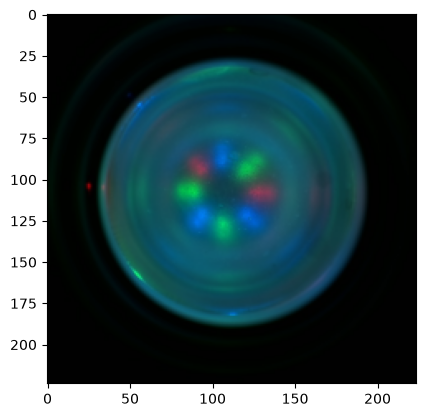

In [114]:
plt.imshow(preprocess_transform(img).permute(1, 2, 0))

QFontDatabase: Cannot find font directory /home/prolex/prokhor_grasp_labeller/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/prolex/prokhor_grasp_labeller/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/prolex/prokhor_grasp_labeller/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/prolex/prokhor_grasp_labeller/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconf

: 

In [12]:
# Should be set in config
top = (256 - 224) // 2   # 16
left = (256 - 224) // 2  # 16

In [13]:
img.shape

(3, 256, 256)

In [15]:
cv2.imshow(img)

error: OpenCV(4.13.0) :-1: error: (-5:Bad argument) in function 'imshow'
> Overload resolution failed:
>  - imshow() missing required argument 'mat' (pos 2)
>  - imshow() missing required argument 'mat' (pos 2)
>  - imshow() missing required argument 'mat' (pos 2)


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

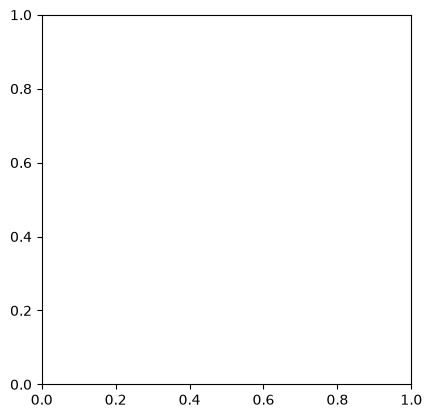

In [14]:
plt.imshow((np.transpose(img[:, 16:240, 16:240]), (1, 2, 0)))
plt.axis("off")
plt.show()

---

In [ ]:
import torch
from huggingface_hub import hf_hub_download
from safetensors.torch import load_file
from tactile_ssl.model import vit_base

device = "cuda" if torch.cuda.is_available() else "cpu"

model = vit_base(
    img_size=(320, 240),
    in_chans=6,
    pos_embed_fn="sinusoidal",
).to(device).eval()

path = hf_hub_download("facebook/sparsh-ijepa-base", "ijepa_vitbase.safetensors")
model.load_state_dict(load_file(path), strict=False)

# x = two RGB tactile images concatenated: [B, 6, 320, 240]
x = torch.rand(1, 6, 320, 240).to(device)

with torch.no_grad():
    tokens = model(x)          # [B, num_patches, 768]
    embedding = tokens.mean(1) # [B, 768]